In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load datasets
calendar = pd.read_csv("../data/calendar_clean.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")

print("Datasets loaded successfully!")
print("Calendar:", calendar.shape)
print("Sales:", sales.shape)

Datasets loaded successfully!
Calendar: (1969, 14)
Sales: (30490, 1919)


In [2]:
# Aggregate daily sales by category and store
sales_cols = [col for col in sales.columns if col.startswith('d_')]
info_cols = ['item_id', 'cat_id', 'dept_id', 'store_id', 'state_id']

# Melt sales data
print("Melting data...")
sales_melted = sales[info_cols + sales_cols].melt(
    id_vars=info_cols,
    var_name='d',
    value_name='sales'
)

# Merge with calendar
sales_melted = sales_melted.merge(
    calendar[['d', 'date', 'month', 'year', 'weekday', 'wday']],
    on='d', how='left'
)

print("Done!")
print("Shape:", sales_melted.shape)

Melting data...
Done!
Shape: (58327370, 12)


Creating weekly aggregation...
Weekly aggregation done!
Shape: (825, 4)

First 5 rows:
   year  week     cat_id  weekly_sales
0  2011     4      FOODS         45936
1  2011     4    HOBBIES          7121
2  2011     4  HOUSEHOLD         11323
3  2011     5      FOODS        145851
4  2011     5    HOBBIES         20214


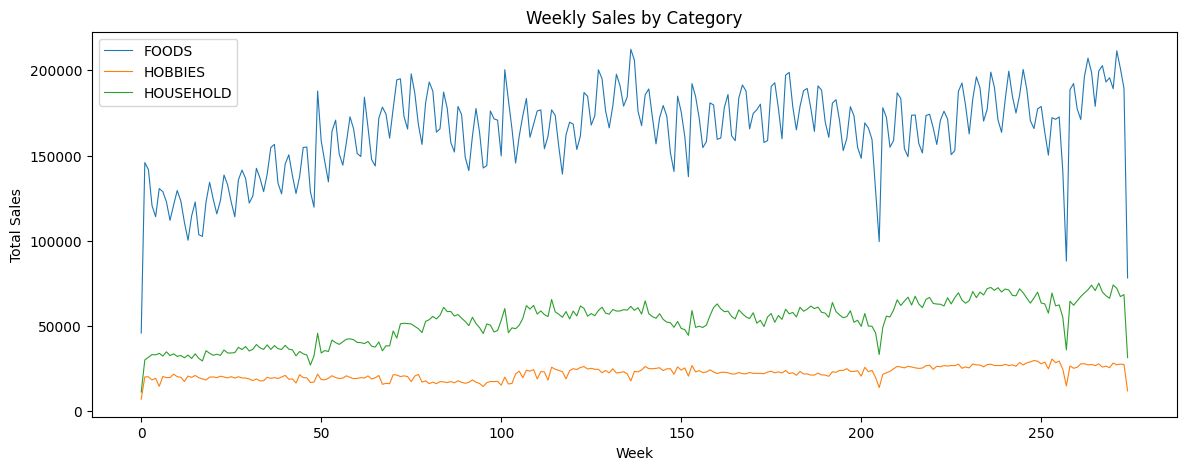

In [3]:
# Weekly Sales Aggregation
print("Creating weekly aggregation...")

sales_melted['date'] = pd.to_datetime(sales_melted['date'])
sales_melted['week'] = sales_melted['date'].dt.isocalendar().week.astype(int)

# Weekly sales by category
weekly_cat = sales_melted.groupby(['year', 'week', 'cat_id'])['sales'].sum().reset_index()
weekly_cat.columns = ['year', 'week', 'cat_id', 'weekly_sales']

print("Weekly aggregation done!")
print("Shape:", weekly_cat.shape)
print("\nFirst 5 rows:")
print(weekly_cat.head())

# Plot weekly sales by category
plt.figure(figsize=(14,5))
for cat in weekly_cat['cat_id'].unique():
    data = weekly_cat[weekly_cat['cat_id'] == cat]
    plt.plot(range(len(data)), data['weekly_sales'], label=cat, linewidth=0.8)
plt.title("Weekly Sales by Category")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

Monthly aggregation done!
Shape: (192, 4)


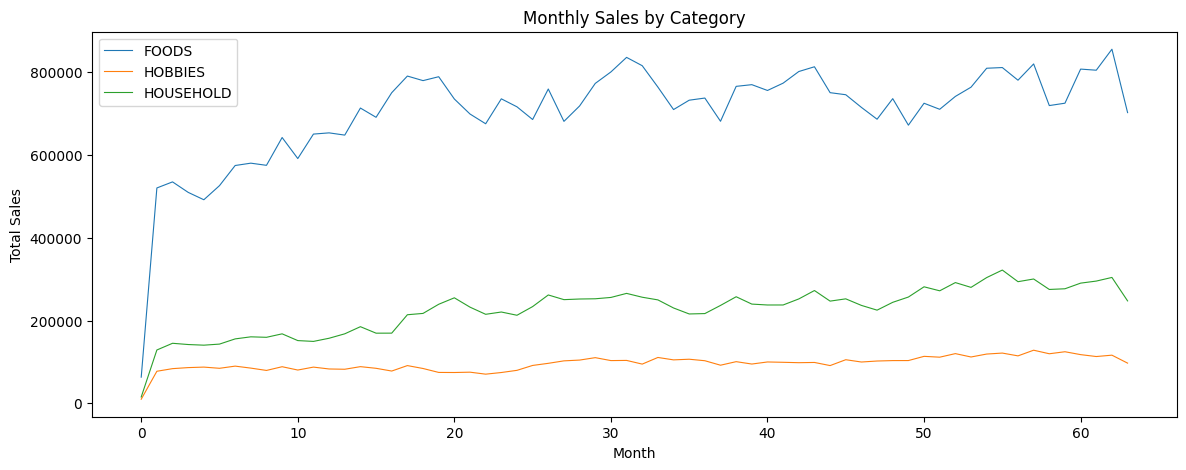


Top 5 stores by monthly sales:
store_id
CA_3    174815.31250
CA_1    120284.62500
TX_2    112724.75000
WI_2    102250.18750
WI_3    100434.09375
Name: monthly_sales, dtype: float64


In [4]:
# Monthly Sales Aggregation
monthly_cat = sales_melted.groupby(['year', 'month', 'cat_id'])['sales'].sum().reset_index()
monthly_cat.columns = ['year', 'month', 'cat_id', 'monthly_sales']

print("Monthly aggregation done!")
print("Shape:", monthly_cat.shape)

# Plot monthly sales by category
plt.figure(figsize=(14,5))
for cat in monthly_cat['cat_id'].unique():
    data = monthly_cat[monthly_cat['cat_id'] == cat]
    plt.plot(range(len(data)), data['monthly_sales'], label=cat, linewidth=0.8)
plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

# Monthly sales by store
monthly_store = sales_melted.groupby(['year', 'month', 'store_id'])['sales'].sum().reset_index()
monthly_store.columns = ['year', 'month', 'store_id', 'monthly_sales']

print("\nTop 5 stores by monthly sales:")
print(monthly_store.groupby('store_id')['monthly_sales'].mean().sort_values(ascending=False).head())

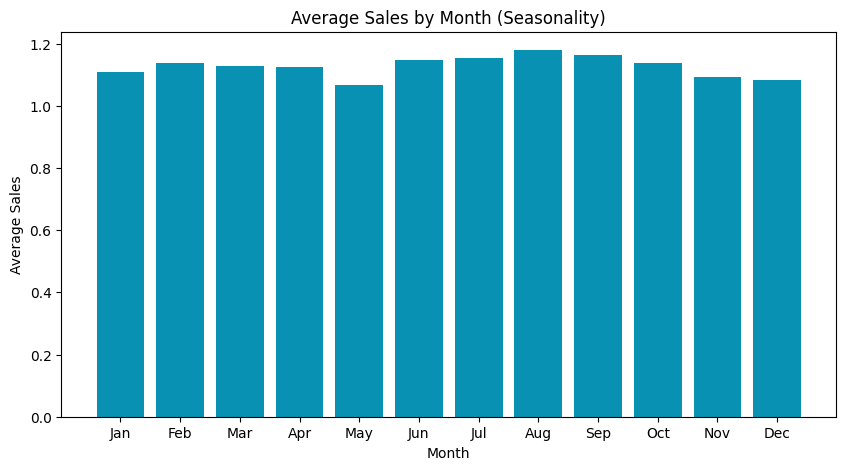

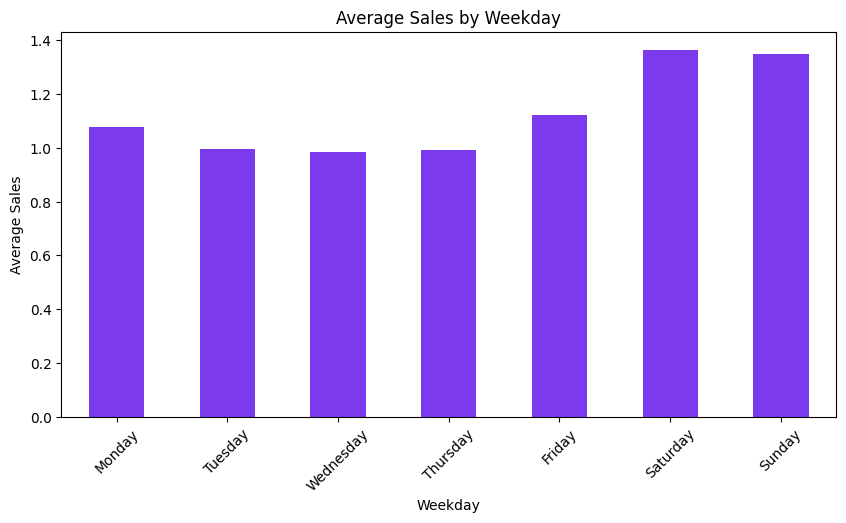

Best Month: 8
Best Weekday: Saturday


In [5]:
# Seasonality Analysis
# Average sales by month across all years
monthly_avg = sales_melted.groupby('month')['sales'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(monthly_avg['month'], monthly_avg['sales'], color='#0891B2')
plt.title("Average Sales by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

# Average sales by weekday
weekday_avg = sales_melted.groupby('weekday')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='#7C3AED')
plt.title("Average Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

print("Best Month:", monthly_avg.loc[monthly_avg['sales'].idxmax(), 'month'])
print("Best Weekday:", weekday_avg.idxmax())

In [ ]:
# Save aggregated data
weekly_cat.to_csv("../data/weekly_sales.csv", index=False)
monthly_cat.to_csv("../data/monthly_sales.csv", index=False)
monthly_store.to_csv("../data/monthly_store_sales.csv", index=False)

print("Aggregated data saved!")

print("\n" + "="*50)
print("WEEK 2 DAY 1 SUMMARY")
print("="*50)
print("Daily data melted: 58,327,370 rows")
print("Weekly aggregation: 825 records")
print("Monthly aggregation complete")
print("\nKey Findings:")
print("Best Month: August")
print("Best Weekday: Saturday")
print("Top Store: CA_3 with 174,815 monthly sales")
print("Top Category: FOODS")
print("="*50)